In [1]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import constants as cst
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [2]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [3]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [4]:
data_path = git_path + "/.submodules/dataset-LJ-fluid/analysis/varying-temperature/"
all_temperatures = np.array([0.8, 1.0, 1.2, 1.5, 1.8, 2.2, 2.6, 3.0]) # unitless
ref_time = 463.7943 # LJ time in fs
ref_temp = 50.3219 # LJ temp in K
cmap_cool = cm.cool
cmap_dark_blue_to_cyan = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(0.0)])
cmap_dark_blue_to_pink = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(1.0)])

In [5]:
spin = 0.5
GAMMA = 2 * np.pi * 42.6e6
K = (3 / 2) * (cst.mu_0 / 4 / np.pi) ** 2 \
    * cst.hbar ** 2 * GAMMA ** 4 * spin * (1 + spin)  # m6 / s2

In [6]:
import matplotlib.pyplot as plt

In [7]:
alltauCvsT = []
for T in all_temperatures:

    alltauC = []
    for n in np.arange(1, 11):
        t, G = np.loadtxt(data_path + f"T{T}/Gij_vs_t_n{n}.dat").T
        tauC = 1/G[0] * np.trapz(G, t)
        alltauC.append(tauC)
    tauC = np.mean(alltauC)
    alltauCvsT.append([T, tauC])
    #     plt.loglog(t, G)
    # plt.show()
alltauCvsT = np.array(alltauCvsT)

In [15]:
filename = "nmr-relaxation-rates-at-target-temp"
colors = cmap_dark_blue_to_pink(np.linspace(0, 1, 50))

T_grivet, R1_grivet = np.loadtxt("grivet-2005-data/data-R1-R2/R1.dat").T
R1_grivet *= K / (3e-10)**6 * (ref_time*1e-15) /6 
T_grivet, R2_grivet = np.loadtxt("grivet-2005-data/data-R1-R2/R2.dat").T
R2_grivet *= K / (3e-10)**6 * (ref_time*1e-15) / 6
_, R1, eR1 = np.loadtxt(data_path+f"R1_at_target_vs_temperature.dat").T
T, R2, eR2 = np.loadtxt(data_path+f"R2_at_target_vs_temperature.dat").T

In [16]:
# (R2-R2_grivet)/R2

In [17]:
# (R1-R1_grivet)/R1

  Pixels: width = 517.4 x height = 518.8
  Aspect ratio: 0.9972
  Pixels: width = 517.4 x height = 518.8
  Aspect ratio: 0.9972


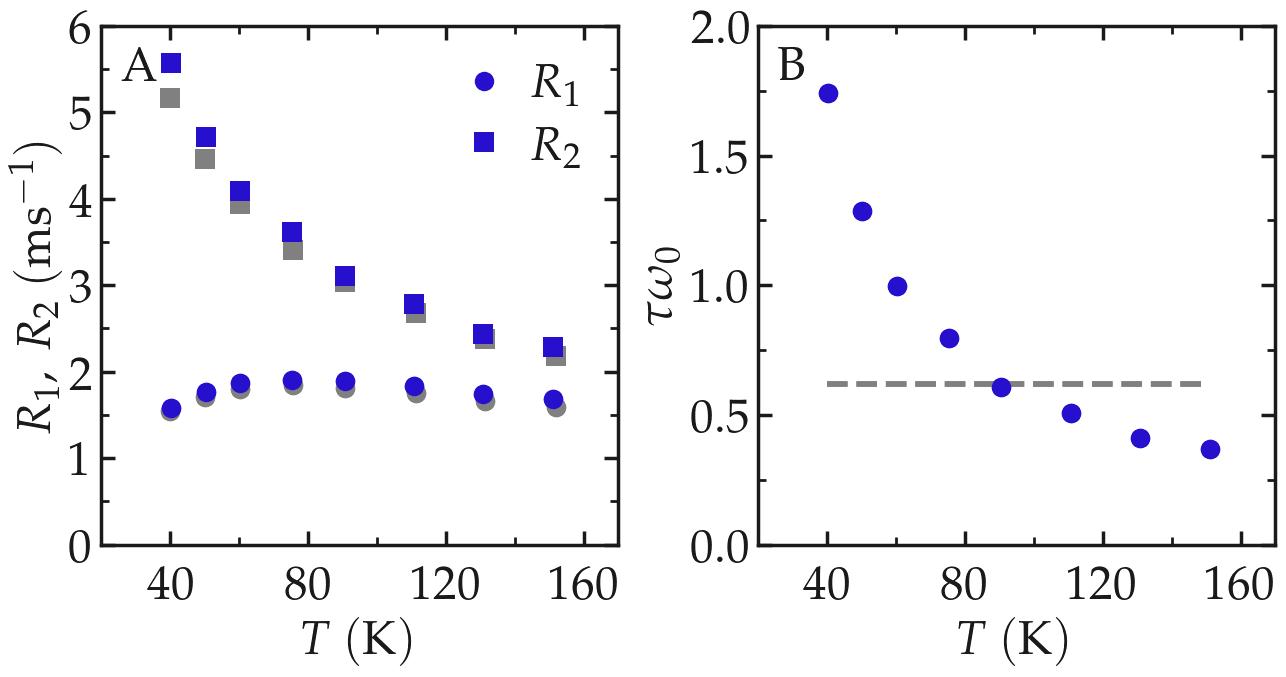

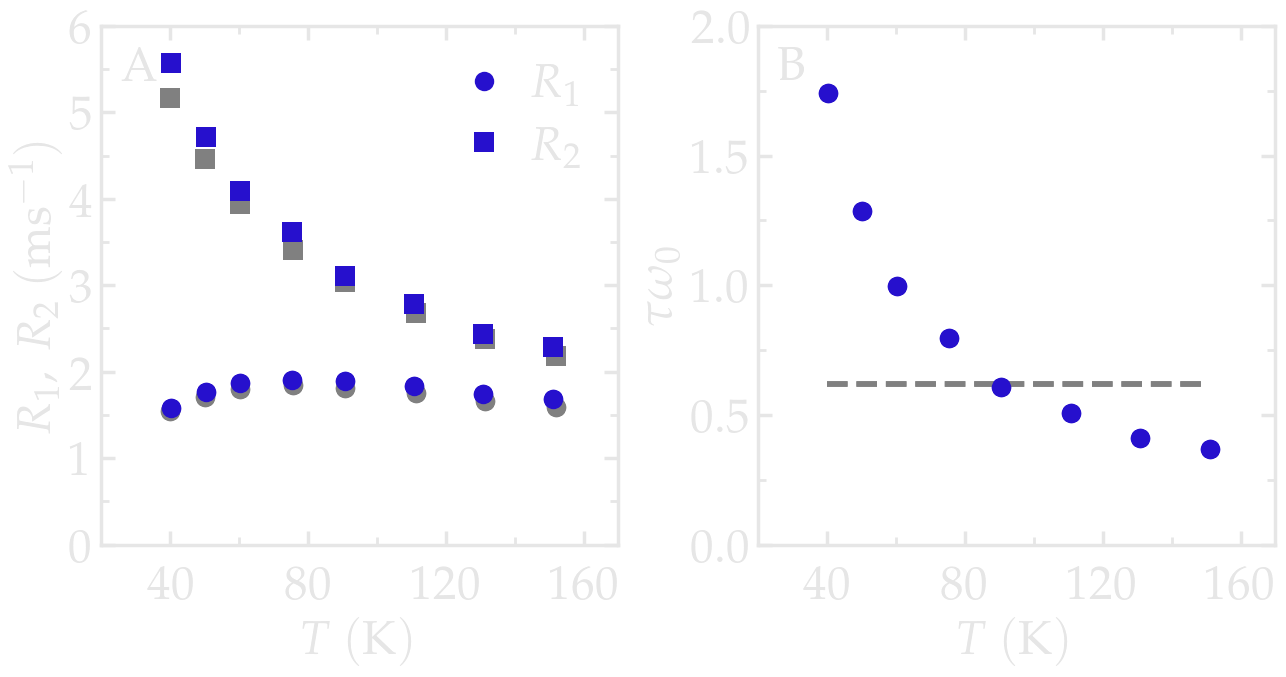

In [18]:
for dark_mode in [False, True]:

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (13,6.88), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2)
    
    # Panel 1
    myplt.add_panel()
    myplt.add_plot(x = T_grivet*ref_temp, y = R1_grivet*1000, type = "plot", linewidth_data = 3,
                marker = "o", data_color = np.array([0.5, 0.5, 0.5]), markersize = 14)
    myplt.add_plot(x = T_grivet*ref_temp, y = R2_grivet*1000, type = "plot", linewidth_data = 3,
                marker = "s", data_color = np.array([0.5, 0.5, 0.5]), markersize = 14)
    myplt.add_plot(x = T*ref_temp, y = R1*1000, type = "plot", linewidth_data = 3,
                marker = "o", data_color = colors[2][:-1], markersize = 14, data_label = r'$R_1$')
    myplt.add_plot(x = T*ref_temp, y = R2*1000, type = "plot", linewidth_data = 3,
                marker = "s", data_color = colors[2][:-1], markersize = 14, data_label = r'$R_2$')
    myplt.complete_panel(ylabel = r'$R_1, ~ R_2~(\mathrm{ms}^{-1})$', xlabel = r'$T~(\mathrm{K})$',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(20, 170), y_boundaries=(0, 6), x_ticks = [40, 80, 120, 160])

    f0 = 150e9 # Hz
    omega0 = 2 * np.pi * f0
    tau = alltauCvsT[:,1]*1e-12 # s

    # Panel 2
    myplt.add_panel()
    x = np.linspace(40, 150)
    myplt.add_plot(x = x, y = x * 0 + 0.62,
                   type = "plot", linewidth_data = 3,
                    marker = "--", data_color = np.array([0.5, 0.5, 0.5]), markersize = 14)
    myplt.add_plot(x = alltauCvsT[:,0]*ref_temp, y = omega0 * tau,
                   type = "plot", linewidth_data = 3,
                    marker = "o", data_color = colors[2][:-1], markersize = 14)
    myplt.complete_panel(ylabel = r'$\tau \omega_0$', xlabel = r'$T~(\mathrm{K})$',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(20, 170), y_boundaries=(0, 2),
                         x_ticks = [40, 80, 120, 160], y_ticks = [0, 0.5, 1.0, 1.5, 2.0])

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = filename, saving_path = git_path+path_figures)

In [36]:
from PIL import Image

for i in [1, 2]:
    if i == 1:
        figure_path = "nmr-relaxation-rates-at-target-temp.png"
        insert_path = "lj-light.png"
        output_path = "nmr-relaxation-rates-at-target.png"
    else:
        figure_path = "nmr-relaxation-rates-at-target-temp-dm.png"
        insert_path = "lj-dark.png"
        output_path = "nmr-relaxation-rates-at-target-dm.png"

    figure = Image.open(figure_path).convert("RGBA")
    insert = Image.open(insert_path).convert("RGBA")

    # Start from the spectrum itself — preserves its own background/transparency
    canvas = figure.copy()

    scale = 0.22
    target_w = int(figure.width * scale)
    target_h = int(insert.height * (target_w / insert.width))
    legend_resized = insert.resize((target_w, target_h), Image.LANCZOS)

    top_margin = 80
    lat_margin = 60
    x = figure.width - target_w - lat_margin
    y = top_margin

    canvas.alpha_composite(legend_resized, (x, y))

    canvas.save(output_path)  # keep as PNG with alpha, don't convert to RGB
    print(f"Saved {output_path}")

Saved nmr-relaxation-rates-at-target.png
Saved nmr-relaxation-rates-at-target-dm.png


In [14]:
# filename = "nmr-relaxation-rates-spectra"
# colors = cmap_cool(np.linspace(0, 1, len(all_temperatures)))

# for dark_mode in [False, True]:

#     myplt = PltTools()
#     myplt.prepare_figure(fig_size = (18,6), dark_mode = dark_mode,
#                          transparency = True, use_serif=True, n_colone = 2)
#     # Panel 1
#     myplt.add_panel()
#     for T, color in zip(all_temperatures, colors):
#         f, R1 = np.loadtxt(data_path+f"T{T}/R1_vs_f.dat").T
#         if ((T == all_temperatures[0]) | (T == all_temperatures[-1])):
#             myplt.add_plot(x = f, y = R1*1000, type = "loglog", linewidth_data = 3,
#                         marker = "o", data_color = color[:3], markersize = 12,
#                         data_label = f'$T = {np.int32(T*ref_temp)}~\mathrm K$')
#         else:
#             myplt.add_plot(x = f, y = R1*1000, type = "loglog", linewidth_data = 3,
#                         marker = "o", data_color = color[:3], markersize = 12) 
#     myplt.complete_panel(ylabel = r'$R_1~(\mathrm{ms}^{-1})$', xlabel = r'$f~(\mathrm{MHz})$',
#                          xpad = 15, legend=True, handlelength_legend=1)
#     myplt.set_boundaries(x_boundaries=(2e4, 3e7), y_boundaries=(4e-2, 2e1))
#     # Panel 2
#     myplt.add_panel()
#     for T, color in zip(all_temperatures, colors):
#         f, R2 = np.loadtxt(data_path+f"T{T}/R2_vs_f.dat").T
#         if ((T == all_temperatures[0]) | (T == all_temperatures[-1])):
#             myplt.add_plot(x = f, y = R2*1000, type = "loglog", linewidth_data = 3,
#                         marker = "o", data_color = color[:3], markersize = 12,
#                         data_label = f'$T = {np.int32(T*ref_temp)}~\mathrm K$')
#         else:
#             myplt.add_plot(x = f, y = R2*1000, type = "loglog", linewidth_data = 3,
#                         marker = "o", data_color = color[:3], markersize = 12) 
#     myplt.complete_panel(ylabel = r'$R_2~(\mathrm{ms}^{-1})$', xlabel = r'$f~(\mathrm{MHz})$',
#                          xpad = 15, legend=True, handlelength_legend=1)
#     myplt.set_boundaries(x_boundaries=(2e4, 3e7), y_boundaries=(4e-1, 2e1))
#     myplt.add_subplotlabels(type_label_panel = "A")
#     myplt.save_figure(filename = filename, saving_path = git_path+path_figures)
